# Assignment 1
## Question 1

Please make sure that you convert Xtest.csv, Xtrain.csv and Ytrain.csv to .txt-files and that they are in the same folder than the excuting files.

In [2]:
#load data
import numpy as np
import matplotlib.pyplot as plt

Xtest = np.loadtxt("Xtest.txt")
Xtrain = np.loadtxt("Xtrain.txt")
Ytrain = np.loadtxt("Ytrain.txt")

### i)

Amount of training examples: 3000
Amount of test examples: 3000


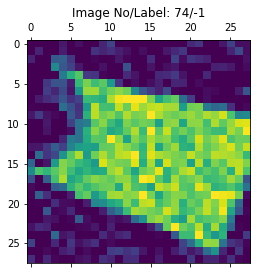

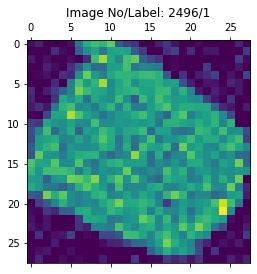

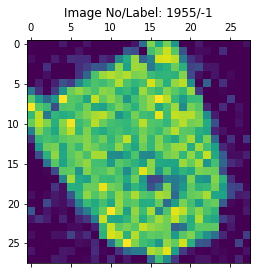

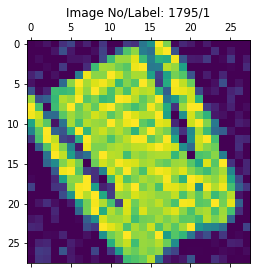

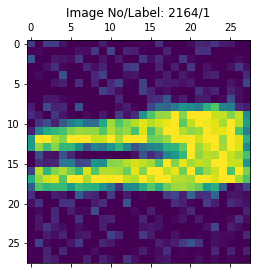

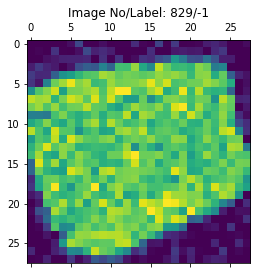

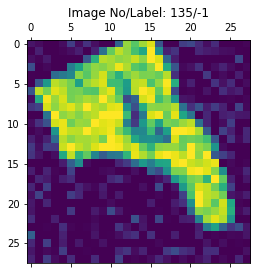

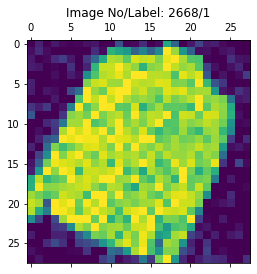

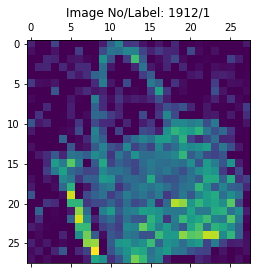

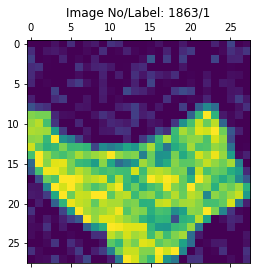

In [3]:
print("Amount of training examples:",len(Xtest))
print("Amount of test examples:",len(Xtrain))

for i in range (0,10):  
    r = np.random.randint(len(Xtest)) #choosing one examples randomly and this ten times
    A = np.reshape(Xtest[r],(28,28))    #rearrange the example in a 28x28 matrix, in order to create the image
    cl = (r,Ytrain[r])
    plt.matshow(A)  #creating image based on the example
    plt.title('Image No/Label: %d/%d' %cl)
    plt.show()

### ii)

In [13]:
# self-explanatory, counting all negative & positive numbers and all zeros entries
# zero is neither positive nor negative I decided to count them as well
def counter(A): 
    pos_count, neg_count, zero_count = 0, 0, 0
    m = len(A[0])
    n = len(A)
    for i in range(n): 
        for j in range(m):  
            if A[i][j] > 0: 
                pos_count += 1
            elif A[i][j] < 0: 
                 neg_count += 1
            else: 
                zero_count += 1                
    return pos_count, neg_count, zero_count,
x = counter(Xtest) #using the counter function on Xtest
print("Amount of pos. numbers: ",x[0],"| Amount of neg. numbers: ",x[1],"| Amount of zeros: ",x[2])

Amount of pos. numbers:  1727998 | Amount of neg. numbers:  0 | Amount of zeros:  624002


### iii)

In [5]:
#%% iii
Ytrain = Ytrain[:,np.newaxis] #adding additional dimension, needed otherwise the function counter would cannot handle Ytrain
x = counter(Ytrain) #using the counter function on Ytrain
print("Amount of pos. numbers: ",x[0],"Amount of neg. numbers: ",x[1],"Amount of zeros: ",x[2])

Amount of pos. numbers:  1824 Amount of neg. numbers:  1176 Amount of zeros:  0


I would not use accuracy as a performance metric and the AUC-ROC neither beacuse one key assumption of both metrics are that the data set is supposed to be balanced.
This is obviusly not the case here beacuse there are arround 61% more positive labels than negative labels. Finally, only the AUC-RC is left.
Nevertheless I would suggest to use the AUC-RC, besides the logic above, because we also want to know the precision of our classifier, independant of the treshold and the AUC_RC is useful for imbalance-classes which is the case here.

### iv)

In [23]:
from sklearn.metrics import confusion_matrix ,balanced_accuracy_score, accuracy_score
x = np.random.randint(1, 1000)*0.001                       #random classifier with random weights
p = int(round(x*3000))                                     #weight times 3000
q = int(round((1-x)*3000))                                 #p and q are linear combination such that q+p=3000 always!
Ypred = np.random.permutation(np.array([+1]*p+[-1]*q))     #random allocating prediction labels with permutation to guarantee a random orderac
#print("confusion_matrix= \n",confusion_matrix(Ytrain, Ypred)) 
print("weight on Y=1: ",round(x,5),"& weight on Y=-1: ",round((1-x),5))
print("accuracy by CPU =",accuracy_score(Ytrain,Ypred))
print("My E[Accuracy] = (x*1824+(1+x)*1179)/3000 =",(x*1824+(1-x)*1179)/3000)

weight on Y=1:  0.838 & weight on Y=-1:  0.162
accuracy by CPU = 0.58
My E[Accuracy] = (x*1824+(1+x)*1179)/3000 = 0.57317


Let the classifier be distrubted the following:<br>
P(Y_C=1) = x and P(Y_C=-1) = (1-x), where x element [1,0]. Then also E[Y] = 1\*x + (-1)\*(1-x) = 2x-1.<br>
We have n = 3000, Frequency(Y=1) = 1824 & Frequency(Y=-1) = 1179, and Frequenzy(Y=1) = n\*fra(Y=1) & Frequenzy(Y=-1) = n\*fra(Y=-1).<br>
Where fra(Y=j) indicates the relative frequency. Fraction of examples labelled as -1 = 0.608 (=fra(Y=1)) &<br>
Fraction of examples labelled as +1 = 0.392 (=fra(Y=-1)).<br>
E[Y_C=1] = x\*3000 & E[Y_C=1] = (1-x)\*3000, E[tp]=x\*Frequency(Y=1) & E[tn]=(1-x)\*Frequency(Y=-1),
where tp is the amount of true postitive allocations and tn is the amount of true neagtive allocations.<br>
With the Linearity of expectation we receive: E[Accuracy] = E[(tp+tn)/n] = (E[tp]+E[tn])/n = (x\*n\*fra(Y=1)+(1-x)\*n\*fra(Y=-1))/n = (x\*fra(Y=1)+(1-x)\*fra(Y=-1)).<br>
As conclusion: E[Accuracy] = (x\*1824+(1+x)\*1179)/3000, where  x element [1,0] determines the distrubution of weights on the binary labels.<br>
Comparing my formula for E[Accuracy] to the calculated accuracy by the CPU you see that they are nearly equal. The deviation results from a numerical rounding error.

### v)

By the CPU we get: AUC-ROC=  0.49906574471894016 and AUC-PR=  0.6075550050350633
AUC-PR calculated by myself =  0.3153526970954357


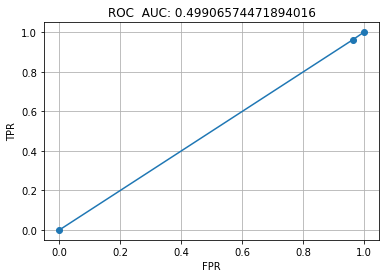

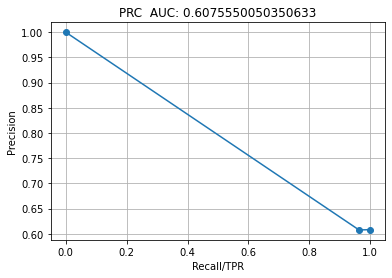

In [11]:
from sklearn.metrics import average_precision_score, roc_curve, roc_auc_score, auc, precision_recall_curve
#similar to evaluation_example.ipynb I am using plotRoc & plotPRC to calculate AUC-Roc and AUC-PR here.
def plotROC(y,z,pstr = ''):
    fpr,tpr,tt = roc_curve(y, z)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr,tpr,'o-');plt.xlabel('FPR');plt.ylabel('TPR');plt.grid();plt.title('ROC '+pstr+' AUC: '+str(roc_auc))
    return roc_auc

def plotPRC(y,z,pstr = ''):
    P,R,tt = precision_recall_curve(y, z)
    pr_auc = average_precision_score(y, z)
    plt.figure()
    plt.plot(R,P,'o-');plt.xlabel('Recall/TPR');plt.ylabel('Precision');plt.grid();plt.title('PRC '+pstr+' AUC: '+str(pr_auc))
    return pr_auc

roc = plotROC(Ytrain,Ypred,'')
pr = plotPRC(Ytrain,Ypred,'')

print("By the CPU we get: AUC-ROC= ",roc,"and AUC-PR= ",pr)

We also use the same designations from the previous task iv) here! <br>
a)<br>
The random classifier allocats each label with some propbality: P(Y_C=1) = x and P(Y_C=-1) = (1-x),<br>
the ROC would look like the function f(x) = x in the intervall [0,1]. <br>
Thats because the TPR and FPR are equal at evry point. But why is TPR(FPR) = FPR?<br>
Mathematical approach:<br>
TPR(x) = TP/F(Y=1) = x\*F(Y=1)/F(Y=1) = x <br>
FPR(x) = FP/F(Y=-1) = x\*F(Y=-1)/F(Y=-1) = x <br>
=> TPR(x) = FPR (x) for all x element [0,1] <br>
Integrating f(x) = x with the integral boundaries 0 and 1 we would get 0.5. Therefore AUCROC = 0.5 for all x element[0,1]<br>
The image of the ROC in the output underlines this and the calculated AUC-ROC is almost 0.5!<br>
b)<br>
Claim: Precision(TPR) = fra(Y=1) = 0.6081<br>
Proof: Precision(TPR) = TP/E[Y=1] = x\*F(Y=1)\/(x\*n) = F(Y=1)\/n = (fra(Y=1)\*n)/n = fra(Y=1) = 0.608 (from previous task we know fra(Y=1) = 0.608)<br>
Intergrating Precision(TPR) = fra(Y=1) in respect to TPR gives us [fra(Y=1)*TPR] with the boundaries 0 and 1. The result is fra(Y=1).
The computed AUC-PR supports the claim.

## Question 2

### Framework

In [24]:
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier

skf = StratifiedKFold(shuffle = True) #default fold=5 & shuffle = true to get an unbiased result
# saving croosvalidation and KNeighborsClassifier procedure in a function to make things easier.
# returning a matrix which saves the mean and the standard deviation of each performance metric
def k5foldcrossvalper(A,B,k, Print = True):   #A = Training feature space, B = Training labels, k parameter for KNN, P query whether to print each Fold
    sknn = KNeighborsClassifier(n_neighbors=k) #initialise nearest Neighbor Classifier dependant on k
    if Print == True:
        print("Folds =",skf.get_n_splits(A, B))  #checking the fold
    mem = np.zeros((3,5))
    for i, (train_index, test_index) in enumerate(skf.split(A, B)):   #Perform 5-fold stratified cross-validation
         Xtr, Xv = A[train_index], A[test_index]
         Ytr, Yv = B[train_index], B[test_index]
         sknn.fit(Xtr,Ytr)
         pred_acc = accuracy_score(Yv,sknn.predict(Xv)) #calculating prediction accuracy for each fold
         auc_roc = roc_auc_score(Yv,sknn.predict(Xv))   #calculating ROC-AUC for each fold
         auc_pr = average_precision_score(Yv,sknn.predict(Xv)) #calculating AUC-PR for each fold
         mem[0,i], mem[1,i], mem[2,i] = pred_acc, auc_roc, auc_pr
         if Print == True:
             print('| %i. Fold | Predicted accuracy = %1.4f | AUC-ROC = %1.4f | AUC-PR = %1.4f |' % (i+1, pred_acc, auc_roc, auc_pr))
    return mem

### i)

In [29]:
 mem = k5foldcrossvalper(Xtrain,Ytrain,1,True)
#application of the k5crossvalper function on Xtrain, Ytrain, 1 Neighbour and activated printing

Folds = 5
| 1. Fold | Predicted accuracy = 0.8283 | AUC-ROC = 0.8242 | AUC-PR = 0.8285 |
| 2. Fold | Predicted accuracy = 0.8067 | AUC-ROC = 0.8009 | AUC-PR = 0.8089 |
| 3. Fold | Predicted accuracy = 0.7900 | AUC-ROC = 0.7872 | AUC-PR = 0.7988 |
| 4. Fold | Predicted accuracy = 0.8533 | AUC-ROC = 0.8537 | AUC-PR = 0.8581 |
| 5. Fold | Predicted accuracy = 0.8083 | AUC-ROC = 0.7993 | AUC-PR = 0.8061 |


### ii)

In [28]:
mean_pa, sd_pa = np.mean(mem[0]), np.std(mem[0])
print('| Prediction accuracy: \t\t\t Mean = %1.4f | standard deviation = %1.4f |' % (mean_pa, sd_pa))
mean_ar, sd_ar = np.mean(mem[1]), np.std(mem[1])
print('| AUC-ROC: \t\t\t\t Mean = %1.4f | standard deviation = %1.4f |' % (mean_ar, sd_ar))
mean_ap, sd_ap = np.mean(mem[2]), np.std(mem[2])
print('| AUC-PR: \t\t\t\t Mean = %1.4f | standard deviation = %1.4f |' % (mean_ap, sd_ap))

| Prediction accuracy: 			 Mean = 0.8233 | standard deviation = 0.0141 |
| AUC-ROC: 				 Mean = 0.8179 | standard deviation = 0.0145 |
| AUC-PR: 				 Mean = 0.8232 | standard deviation = 0.0126 |


### iii)

In [91]:
from sklearn import preprocessing
import time as time


# =============================================================================
# According to the provided source (https://scikitlearn.org/stable/modules/preprocessing.html),there are various of froms
# of pre-processing. In principle, under pre-processing is understood the transformation of a raw feature space
# in to a more manageable or suitable one.
# In the following I will introduce you to three of those pre-processing transforamtions. 
# =============================================================================

#Standardization via standardscalar
print("1.) Standardization")
stand = preprocessing.StandardScaler().fit(Xtrain)
r = np.random.randint(0,778)
print("Mean of 5 random features: ", stand.mean_[r:r+5])
Xtr_scaled = stand.transform(Xtrain) #sclaing each example in Xtrain , scaledfeature = (feature - mean(features)) / standarddeviation(features)
print("Mean of the 5 the scaled random features: \n", Xtr_scaled.mean(axis=0)[r:r+5])
print("Std of the 5 the scaled random features: ", Xtr_scaled.std(axis=0)[r:r+5])
#Checking cross-validation performance
StPerform = k5foldcrossvalper(Xtr_scaled, Ytrain,1,True)

mean_pa, sd_pa = np.mean(StPerform[0]), np.std(StPerform[0])
mean_ar, sd_ar = np.mean(StPerform[1]), np.std(StPerform[1])
mean_ap, sd_ap = np.mean(StPerform[2]), np.std(StPerform[2])
print('---------------------------------------------------------------------------------------------------')
print('| Total\t  | mean = %1.4f \t\t| mean = %1.4f\t   | mean = %1.4f   |' % (mean_pa, mean_ar, mean_ap))
print('| Total\t  | std = %1.4f  \t\t| std = %1.4f\t   | std = %1.4f    |' % (sd_pa, sd_ar, sd_ap))


#Generating polynomial features
print("2.) Generating polynomial features")
# =============================================================================
# "Often it’s useful to add complexity to the model by considering nonlinear features of the input data. A simple and common method to use is polynomial features,
# which can get features’ high-order and interaction terms"
# =============================================================================

poly = preprocessing.PolynomialFeatures(3) #Are our features maybe complexer and follow polynomialring of the grade 3?
try:    #testing for MemoryError
    poly.fit_transform(Xtrain) 
except MemoryError:
   print("Degree = 3 delivers MemoryError")
# This results in an error because the the transformed feature space would be too big to handle for a commercially available CPU. To be precise an array of the form (3000, 80931145).
# okay so lets use "only" a degree of 2

poly = preprocessing.PolynomialFeatures(2) #Are our features maybe complexer and follow polynomialring of the grade 2?
try:    #testing for MemoryError
    poly.fit_transform(Xtrain)
    print("Well, we are able to tansform the data, but are we going to be able to classify it?")
    start_time = time.time()
    PolyPred = k5foldcrossvalper(poly.fit_transform(Xtrain) , Ytrain, 1, True)
    end_time = time.time()
    time_lapsed = end_time - start_time
    if time_lapsed > 1:
        print("Well we terminated it, but at what price? I took us",time_lapsed,"hours")
except MemoryError:
    print("Degree = 2 delivers MemoryError")


#Normalization
print("3.) Normalization")
# =============================================================================
# "Normalization is the process of scaling individual samples to have unit norm.
# This process can be useful if you plan to use a quadratic form such as the dot-product or
# any other kernel to quantify the similarity of any pair of samples."
# =============================================================================

normalizer = preprocessing.Normalizer().fit(Xtrain) #default=’l2’ l2 refers to the  Euclidean norm or l^2 norm - here we normalized Xtrain
Xtr_normalized = normalizer.transform(Xtrain) #Normalization of Xtrain on Xtrain
NormPerform = k5foldcrossvalper(Xtr_normalized, Ytrain,1,True)

mean_pa, sd_pa = np.mean(NormPerform[0]), np.std(NormPerform[0])
mean_ar, sd_ar = np.mean(NormPerform[1]), np.std(NormPerform[1])
mean_ap, sd_ap = np.mean(NormPerform[2]), np.std(NormPerform[2])
print('---------------------------------------------------------------------------------------------------')
print('| Total\t  | mean = %1.4f \t\t| mean = %1.4f\t   | mean = %1.4f   |' % (mean_pa, mean_ar, mean_ap))
print('| Total\t  | std = %1.4f  \t\t| std = %1.4f\t   | std = %1.4f    |' % (sd_pa, sd_ar, sd_ap))

1.) Standardization
Mean of 5 random features:  [20.62566667 37.40166667 55.47833333 66.323      75.294     ]
Mean of the 5 the scaled random features: 
 [-3.48494382e-16  3.33066907e-19  3.54013115e-16 -7.39778609e-17
  5.07741997e-17]
Std of the 5 the scaled random features:  [1. 1. 1. 1. 1.]
Folds = 5
| 1. Fold | Predicted accuracy = 0.8367 | AUC-ROC = 0.8274 | AUC-PR = 0.8285 |
| 2. Fold | Predicted accuracy = 0.8233 | AUC-ROC = 0.8252 | AUC-PR = 0.8336 |
| 3. Fold | Predicted accuracy = 0.8150 | AUC-ROC = 0.8093 | AUC-PR = 0.8159 |
| 4. Fold | Predicted accuracy = 0.8283 | AUC-ROC = 0.8316 | AUC-PR = 0.8401 |
| 5. Fold | Predicted accuracy = 0.8183 | AUC-ROC = 0.8143 | AUC-PR = 0.8210 |
---------------------------------------------------------------------------------------------------
| Total	  | mean = 0.8243 		| mean = 0.8216	   | mean = 0.8278   |
| Total	  | std = 0.0076  		| std = 0.0084	   | std = 0.0086    |
2.) Generating polynomial features
Degree = 3 delivers MemoryError

Unfortunately, my computational capacities are not sufficient enough to generate polynomial features. In this run it got canceled while calculating cross-validation performance after the first fold. Nevertheless, this method is also more applicable with a small number of feautures.
When comparing the unpre-processed feature space with the standardised you cannot detect any significant difference, except that the standard deviation marginally decreased. However, if you look at the normalized data set you detect signifacnt differences in cross validation performance. Predicted accuracy could increase by 3% points, the AUC-ROC by around 2% points and the AUC-PR by around 1.5%, compared to the standardised feature space.

### iv)

max point of prediction accuracy: k= 9 Mean(PA)= 0.8353
max point of AUC-ROC: k= 9 Mean(AUC-ROC)= 0.8325
max point of AUC-PR: k= 8 Mean(AUC-PR)= 0.8418
cross-validation performance for k= 8
Folds = 5
| 1. Fold | Predicted accuracy = 0.8117 | AUC-ROC = 0.8224 | AUC-PR = 0.8358 |
| 2. Fold | Predicted accuracy = 0.8133 | AUC-ROC = 0.8178 | AUC-PR = 0.8285 |
| 3. Fold | Predicted accuracy = 0.8500 | AUC-ROC = 0.8479 | AUC-PR = 0.8514 |
| 4. Fold | Predicted accuracy = 0.8183 | AUC-ROC = 0.8287 | AUC-PR = 0.8420 |
| 5. Fold | Predicted accuracy = 0.8233 | AUC-ROC = 0.8305 | AUC-PR = 0.8416 |
---------------------------------------------------------------------------------------------------
| Total	  | mean = 0.8233 		| mean = 0.8295	   | mean = 0.8399   |
| Total	  | std = 0.0139  		| std = 0.0103	   | std = 0.0076    |


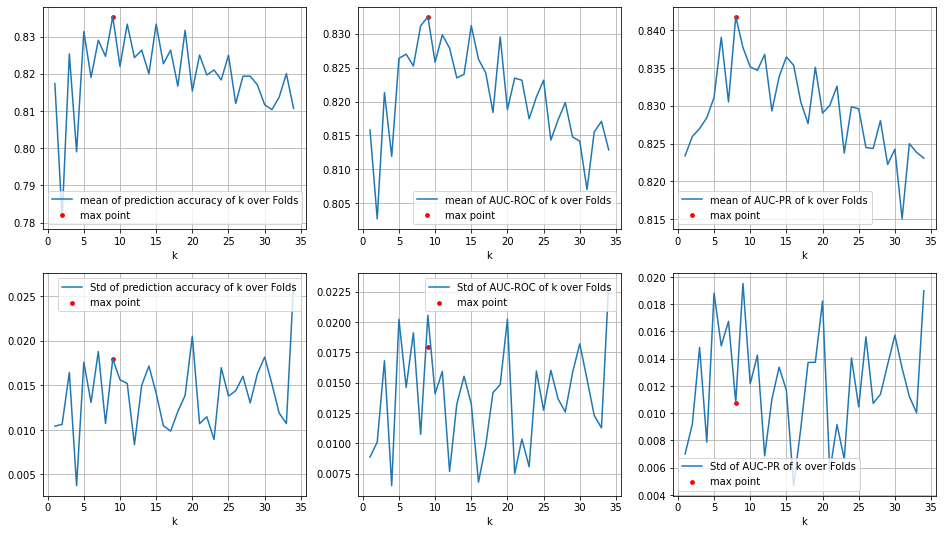

In [114]:
import matplotlib.pyplot as plt

means = np.zeros((34,4)) #saving mean and dtandard deviation later in this arrays
stds = np.zeros((34,3))

for k in range(1,35):   #k element [1,34], I choose this interval because sqrt(784) = 28 and
                        #the following six k to see the devolpment after the root?
    #print("k= ",k)
    mem2 = k5foldcrossvalper(Xtr_scaled ,Ytrain,k, False)
    #excecuting knn  for each k and saving their perfomance in mem2 for each k - using the standardized data bc it leads to a higher cross-validation performance
    means[k-1,0] = int(k)
    means[k-1,1], stds[k-1,0] = np.mean(mem2[0]), np.std(mem2[0]) #calculating for each k the mean and the standard deviation of the prediction accuracy, AUC-ROC and AUC-PR over the 5 folds.
    means[k-1,2], stds[k-1,1] = np.mean(mem2[1]), np.std(mem2[1])
    means[k-1,3], stds[k-1,2] = np.mean(mem2[2]), np.std(mem2[2])

#plotting a graph of prediction accuracy, AUC-ROC and AUC-PR dependant on k
fig, ((m1, m2, m3), (st1, st2, st3)) = plt.subplots(2, 3,figsize=(16,9))
#plt.subplot(131)

m1.plot(means[:,0], means[:,1])
m1.scatter(np.argmax(means[:,1])+1, np.amax(means[:,1]), s=14, marker='o', color ='red')
m1.grid(True)
m1.legend(('mean of prediction accuracy of k over Folds','max point'))
m1.set(xlabel='k')

st1.plot(means[:,0], stds[:,0])
st1.scatter(np.argmax(means[:,1])+1, stds[np.argmax(means[:,1]),0], s=14, marker='o', color ='red')
st1.grid(True)
st1.legend(('Std of prediction accuracy of k over Folds','max point'),loc="upper right")
st1.set(xlabel='k')

m2.plot(means[:,0], means[:,2])
m2.scatter(np.argmax(means[:,2])+1, np.amax(means[:,2]), s=14, marker='o', color ='red')
m2.grid(True)
m2.legend(('mean of AUC-ROC of k over Folds','max point'))
m2.set(xlabel='k')

st2.plot(means[:,0], stds[:,1])
st2.scatter(np.argmax(means[:,2])+1, stds[np.argmax(means[:,2]),0], s=14, marker='o', color ='red')
st2.grid(True)
st2.legend(('Std of AUC-ROC of k over Folds','max point'),loc="upper right")
st2.set(xlabel='k')                 

m3.plot(means[:,0], means[:,3])
m3.scatter(np.argmax(means[:,3])+1, np.amax(means[:,3]), s=14, marker='o', color ='red')
m3.grid(True)
m3.legend(('mean of AUC-PR of k over Folds','max point'),loc="lower left")
m3.set(xlabel='k')

st3.plot(means[:,0], stds[:,2])
st3.scatter(np.argmax(means[:,3])+1, stds[np.argmax(means[:,3]),0], s=14, marker='o', color ='red') #idk why it does not find the right point :(
st3.grid(True)
st3.legend(('Std of AUC-PR of k over Folds','max point'),loc="lower left")
st3.set(xlabel='k')

print("max point of prediction accuracy: k= %i Mean(PA)= %1.4f" % (np.argmax(means[:,1])+1, np.amax(means[:,1])))
print("max point of AUC-ROC: k= %i Mean(AUC-ROC)= %1.4f" % (np.argmax(means[:,2])+1, np.amax(means[:,2])))
print("max point of AUC-PR: k= %i Mean(AUC-PR)= %1.4f" % (np.argmax(means[:,3])+1, np.amax(means[:,3])))
print("cross-validation performance for k=", np.argmax(means[:,3])+1)
opt = k5foldcrossvalper(Xtr_scaled,Ytrain,np.argmax(means[:,3])+1, True)
mean_pa, sd_pa = np.mean(opt[0]), np.std(opt[0])
mean_ar, sd_ar = np.mean(opt[1]), np.std(opt[1])
mean_ap, sd_ap = np.mean(opt[2]), np.std(opt[2])
print('---------------------------------------------------------------------------------------------------')
print('| Total\t  | mean = %1.4f \t\t| mean = %1.4f\t   | mean = %1.4f   |' % (mean_pa, mean_ar, mean_ap))
print('| Total\t  | std = %1.4f  \t\t| std = %1.4f\t   | std = %1.4f    |' % (sd_pa, sd_ar, sd_ap))

As you see in the plot I would recommend a k element {8,9}. Here the mean of prediction accuracy, AUC-ROC and AUC-PR are at their highest. You can see in plot as well, that the performance of the diffrent metrics decrease rapidly after k is greater than ten. <br>
Finally I would choose k=8 because here we have the maximum of AUC-PR, and only marginal loses in prediction accuracacy  and AUC-ROC. What also makes k=8 attractive is the relatively low standard deviation. This also gives us a certain degree of certainty that there are no outliers in the sample of folds. Choosing k=9 would lead to a loss of AUC-PR by over 1.5% points.
The arguments from Q1 v) support my argumentation.

## Question 3

In [112]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, average_precision_score, roc_auc_score
skf = StratifiedKFold(shuffle = True)
from sklearn import preprocessing

normalizer = preprocessing.Normalizer().fit(Xtrain) #default=’l2’ l2 refers to the  Euclidean norm or l^2 norm - here we normalized Xtrain
Xtrain_n = normalizer.transform(Xtrain) #Normalization of Xtrain
#only used when cross-validation performance is better than without pre-processing

# k-nearest neighbour
from sklearn.neighbors import KNeighborsClassifier

n=2
accuracy = np.zeros((n,2))
auc_roc = np.zeros((n,2))
auc_pr = np.zeros((n,2))

for k in range (1,n+1): #searchin for the best k in the intervall [1,31]
    sknn = KNeighborsClassifier(n_neighbors=k)
    acc = cross_val_score(sknn, Xtrain, Ytrain, scoring = 'accuracy',cv=skf) #reporting accuracy for each fold 
    ar = cross_val_score(sknn, Xtrain, Ytrain, scoring = 'roc_auc',cv=skf)  #reporting AUC-ROC for each fold 
    ap = cross_val_score(sknn, Xtrain, Ytrain, scoring = 'average_precision',cv=skf)    #reporting AUC-PR for each fold 
    accuracy[k-1,0],  accuracy[k-1,1] = np.mean(acc), np.std(acc) #saving means and the std over the fold for each performance metric
    auc_roc[k-1,0], auc_roc[k-1,1] = np.mean(ar), np.std(ar)
    auc_pr[k-1,0], auc_pr[k-1,1] = np.mean(ap), np.std(ap)
    
optik = np.argmax(auc_pr[:,0])    
print("\nK-Nearest Neighbor with k = %i such that AUC-PR is optimal" % (np.argmax(auc_pr[:,0])+1))
print("| cross validation results\t| predicted accuracy\t| AUC-ROC \t| Best AUC-PR\t|")
print('---------------------------------------------------------------------------------------------------')
print('| Total\t\t\t\t| mean = %1.4f \t| mean = %1.4f\t| mean = %1.4f\t|' % (accuracy[optik,0], auc_roc[optik,0], np.max(auc_pr[:,0])))
print('| Total\t\t\t\t| std = %1.4f \t\t| std = %1.4f\t| std = %1.4f\t|' % (accuracy[optik,1], auc_roc[optik,1], auc_pr[optik,1]))

# Perceptron
from sklearn.linear_model import Perceptron
perc = Perceptron(tol=1e-3, random_state=True)
mem = np.zeros((3,5)) #saving the results of PA, AUC-PR, AUC-PR for the 5-fold strat. cross-validation. Is overwritten again and again in the course of the code for different classifiers

for i, (train_index, test_index) in enumerate(skf.split(Xtrain_n, Ytrain)):   #Perform 5-fold stratified cross-validation
         Xtr, Xv = Xtrain_n[train_index], Xtrain_n[test_index]
         Ytr, Yv = Ytrain[train_index], Ytrain[test_index]
         perc.fit(Xtr,Ytr)
         pred_acc = accuracy_score(Yv,perc.predict(Xv)) #calculating prediction accuracy for each fold
         auc_roc = roc_auc_score(Yv,perc.predict(Xv))   #calculating ROC-AUC for each fold
         auc_pr = average_precision_score(Yv,perc.predict(Xv)) #calculating AUC-PR for each fold
         mem[0,i], mem[1,i], mem[2,i] = pred_acc, auc_roc, auc_pr
         #print('| %i. Fold\t| Predicted accuracy = %1.4f\t| AUC-ROC = %1.4f\t| AUC-PR = %1.4f\t|' % (i+1, pred_acc, auc_roc, auc_pr))
print("\nPerceptron")
print("| cross validation results\t| Predicted accuracy \t| AUC-ROC \t| AUC-PR \t|")
print('---------------------------------------------------------------------------------------------------')
print('| Total\t\t\t\t| mean = %1.4f \t| mean = %1.4f\t| mean = %1.4f\t| ' % (np.mean(mem[0]), np.mean(mem[1]), np.mean(mem[2])))
print('| Total\t\t\t\t| std = %1.4f \t\t| std = %1.4f\t| std = %1.4f\t| ' % (np.std(mem[0]), np.std(mem[1]), np.std(mem[2])))

#nothing to optimize here. In the broadest sense, one could determine the maximum iteration steps of the perceptron algorithm.
#However, this parameter is set by default in such a way that the algorithm stops after 5 iteration steps that do not show any significant improvement in accuracy.

# Naive Bayes Classifier (NBC)
# So now wir have the choice between diffrent kinds of NBCs. (Gaussian, Multinomial, Complement, Bernoulli & Categorical)
# Obviously our features are not Bernoulli destributed, as you can see in the training data set.
# Complement and Multinomial we can exclude as well because they are mostly used for "text" recognition.
# I would stick to the categorial distribution. Becuase we know the maximum of each feature space.
# Due each example maps a image we know that each featurevalue refers to a pixel which take binary values from 0 to 255.
# This refers to the 24-bit RGB color presentation.
# This assumption gets confirmed by having a look on the max and min values of Xtrain. 
# min(Xtrain) = 0 while max(Xtrain) = 255

from  sklearn.naive_bayes import CategoricalNB
# there is a problem with the preinstalled package naiv_bayes. It does not contain the option to choose min_categories!!!!
# therefore go in the explorer and replace the code of the file naive_bays with the following code: https://github.com/scikit-learn/scikit-learn/blob/95119c13a/sklearn/naive_bayes.py#L1054
# or update sklearn to 0.24.1 !!
"""
r =np.random.randint(0,785) 
pixelcoulour, frequencies = np.unique(Xtrain[:,5], return_counts=True) #counting the frequencie of each pixel in a random feature 
fig, ax = plt.subplots()
plt.title("The %ith feature and its frequency/categorical distribution" % (r))
plt.ylabel('Frequencie of colour')
plt.xlabel("Colour as integer")
plt.bar(pixelcoulour, frequencies,width= 2,align='center') #visulization of the result as bar graph
ax.set_yscale('log')
plt.show()
"""
mem = np.zeros((3,5))
cate = CategoricalNB(fit_prior=True, min_categories = 256) #fir_pror = True prevents uniform distribution

for i, (train_index, test_index) in enumerate(skf.split(Xtrain, Ytrain)):   #Perform 5-fold stratified cross-validation
         Xtr, Xv = Xtrain[train_index], Xtrain[test_index]
         Ytr, Yv = Ytrain[train_index], Ytrain[test_index]
         cate.fit(Xtr,Ytr)
         pred_acc = accuracy_score(Yv,cate.predict(Xv)) #calculating prediction accuracy for each fold         
         auc_roc = roc_auc_score(Yv,cate.predict(Xv))   #calculating ROC-AUC for each fold
         auc_pr = average_precision_score(Yv,cate.predict(Xv)) #calculating AUC-PR for each fold
         mem[0,i], mem[1,i], mem[2,i] = pred_acc, auc_roc, auc_pr
         #print('| %i. Fold\t| Predicted accuracy = %1.4f\t| AUC-ROC = %1.4f\t| AUC-PR = %1.4f\t|' % (i+1, pred_acc, auc_roc, auc_pr))
print("\nCategorical Naive Bayes")
print("| cross validation results\t| Predicted accuracy \t| AUC-ROC \t| AUC-PR \t|")
print('---------------------------------------------------------------------------------------------------')
print('| Total\t\t\t\t| mean = %1.4f \t| mean = %1.4f\t| mean = %1.4f\t| ' % (np.mean(mem[0]), np.mean(mem[1]), np.mean(mem[2])))
print('| Total\t\t\t\t| std = %1.4f \t\t| std = %1.4f\t| std = %1.4f\t| ' % (np.std(mem[0]), np.std(mem[1]), np.std(mem[2])))
#no parameter to optimitation here

#Logisic regression
from sklearn.linear_model import LogisticRegression
mem = np.zeros((3,5))
LR = LogisticRegression(penalty='l2', dual=False, tol=0.0001, fit_intercept=True, solver='lbfgs', random_state=True, max_iter=100)
# default amount of iterations is not sufficent, an other solver (optimizer) than the lbfgs (refers to Broyden–Fletcher–Goldfarb–Shanno algorithm) would go beyond the time frame 
# Prefer dual=False when n_samples > n_features.
# usage of pre-processed data (normalized) beaucse cross-validation performance is better and significantly fewer iteration steps. From over 5000 to less than 100 now! 
for i, (train_index, test_index) in enumerate(skf.split(Xtrain_n, Ytrain)):   #Perform 5-fold stratified cross-validation
         Xtr, Xv = Xtrain_n[train_index], Xtrain_n[test_index]
         Ytr, Yv = Ytrain[train_index], Ytrain[test_index]
         LR.fit(Xtr, Ytr)
         A = LR.predict(Xv)
         pred_acc = accuracy_score(Yv,LR.predict(Xv)) #calculating prediction accuracy for each fold        
         auc_roc = roc_auc_score(Yv,LR.predict(Xv))   #calculating ROC-AUC for each fold
         auc_pr = average_precision_score(Yv,LR.predict(Xv)) #calculating AUC-PR for each fold
         mem[0,i], mem[1,i], mem[2,i] = pred_acc, auc_roc, auc_pr
         #print('| %i. Fold\t| Predicted accuracy = %1.4f\t| AUC-ROC = %1.4f\t| AUC-PR = %1.4f\t|' % (i+1, pred_acc, auc_roc, auc_pr))
print("\nLogisticRegression with C=1 (default)")
print("| cross validation results\t| Predicted accuracy \t| AUC-ROC \t| AUC-PR \t|")
print('---------------------------------------------------------------------------------------------------')
print('| Total\t\t\t\t| mean = %1.4f \t| mean = %1.4f\t| mean = %1.4f\t| ' % (np.mean(mem[0]), np.mean(mem[1]), np.mean(mem[2])))
print('| Total\t\t\t\t| std = %1.4f \t\t| std = %1.4f\t| std = %1.4f\t| ' % (np.std(mem[0]), np.std(mem[1]), np.std(mem[2])))
#optimize C now with grid search
#GridSearchCV is inefficent and more like a brute force, trying a lot of parameters
searchpara = [0.1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144] #the parameters according to fibunacci sequence, values lower than one are do not lead an encrease of precesion
n= len(searchpara)
accuracy = np.zeros((n,2))
auc_roc = np.zeros((n,2))
auc_pr = np.zeros((n,2))

for c in enumerate(searchpara):
    sp = searchpara[c[0]]
    c = c[0]
    LR = LogisticRegression(C=sp, max_iter=1000) #default iteration steps are not enough even though I am using the normalized data
    acc = cross_val_score(LR, Xtrain_n, Ytrain, scoring = 'accuracy', cv=skf)
    ar = cross_val_score(LR, Xtrain_n, Ytrain, scoring = 'roc_auc', cv=skf)
    ap = cross_val_score(LR, Xtrain_n, Ytrain, scoring = 'average_precision', cv=skf)
    accuracy[c,0],  accuracy[c,1] = np.mean(acc), np.std(acc)
    auc_roc[c,0], auc_roc[c,1] = np.mean(ar), np.std(ar)
    auc_pr[c,0], auc_pr[c,1] = np.mean(ap), np.std(ap)

print("\nLogisticRegression with C = %i such that AUC-PR is optimal" % (searchpara[np.argmax(auc_pr[:,0])]))
print("| cross validation results\t| Predicted accuracy \t| AUC-ROC \t| Best AUC-PR \t|")
print('---------------------------------------------------------------------------------------------------')
print('| Total\t\t\t\t| mean = %1.4f \t| mean = %1.4f\t| mean = %1.4f\t| ' % ( accuracy[np.argmax(auc_pr[:,0]),0], auc_roc[np.argmax(auc_pr[:,0]),0], np.max(auc_pr[:,0])))
print('| Total\t\t\t\t| std = %1.4f \t\t| std = %1.4f\t| std = %1.4f\t| ' % (accuracy[np.argmax(auc_pr[:,0]),1], auc_roc[np.argmax(auc_pr[:,0]),1], auc_pr[np.argmax(auc_pr[:,0]),1]))


# Linear SVM & KernelizedSVM
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

searchpara = [{'kernel': ['linear'], 'C': [0.1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144]}] #first eleven numbers of fibunacci sequence and one lower than 1
gs = GridSearchCV(SVC(), searchpara, scoring='average_precision', cv= skf) #using gridsearch to find best parameter for C, such that average precision is optimized
gs.fit(Xtrain_n, Ytrain)
lsvm = SVC(C = gs.best_params_['C'], kernel = 'linear', class_weight = 'balanced')
m_acc, std_acc = np.mean(cross_val_score(lsvm, Xtrain_n, Ytrain, scoring = 'accuracy', cv=skf)),  np.std(cross_val_score(lsvm, Xtrain_n, Ytrain, scoring = 'accuracy', cv=skf))
m_ar, std_ar = np.mean(cross_val_score(lsvm, Xtrain_n, Ytrain, scoring = 'roc_auc', cv=skf)), np.std(cross_val_score(lsvm, Xtrain_n, Ytrain, scoring = 'roc_auc', cv=skf))
m_ap, std_ap = np.mean(cross_val_score(lsvm, Xtrain_n, Ytrain, scoring = 'average_precision', cv=skf)), np.std(cross_val_score(lsvm, Xtrain_n, Ytrain, scoring = 'average_precision', cv=skf))

print("\nLinear Support Vector Machine with C = %i such that AUC-PR is optimal" % (gs.best_params_['C']))
print("| cross validation results\t| Predicted accuracy \t| AUC-ROC t\| Best AUC-PR \t|")
print('---------------------------------------------------------------------------------------------------')
print('| Total\t\t\t\t| mean = %1.4f \t| mean = %1.4f\t| mean = %1.4f\t| ' % (m_acc, m_ar, m_ap))
print('| Total\t\t\t\t| std = %1.4f \t\t| std = %1.4f\t| std = %1.4f\t| ' % (std_acc, std_ar, std_ap))

#%% Kernelized SVM
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

searchpara = [{'kernel': ['rbf'], 'gamma': [1e-2, 1e-3, 1e-4],'C': [0.001, 0.1, 1, 2, 3, 5, 8, 13, 21, 34, 55],'class_weight': ['balanced']},
              {'kernel': ['poly'], 'coef0':[0,1] ,'gamma': [1e-2, 1e-3, 1e-4], 'degree': [0.5, 2, 3],'C': [0.001, 0.1, 1, 2, 3, 5, 8, 13, 21, 34, 55],'class_weight': ['balanced']},
              {'kernel': ['sigmoid'], 'coef0':[0,1] ,'gamma': [1e-2, 1e-3, 1e-4], 'C': [0.001, 0.1, 1, 2, 3, 5, 8, 13, 21, 34, 55],'class_weight': ['balanced']}]
#analyzed kernels: RBF, Polynomial and Sigmoid
gs = GridSearchCV(SVC(), searchpara, scoring='average_precision', cv= skf) #overwrite gs from linear svm with gridsearch
# to find best parameter for C and the best Kernel, such that average precision is optimized
gs.fit(Xtrain_n, Ytrain)

print(gs.best_params_)
ksvm = SVC(C = gs.best_params_['C'], degree = gs.best_params_['degree'], gamma =  gs.best_params_['gamma'], kernel = gs.best_params_['kernel'], class_weight = 'balanced')
m_acc, std_acc = np.mean(cross_val_score(ksvm, Xtrain_n, Ytrain, scoring = 'accuracy', cv=skf)),  np.std(cross_val_score(ksvm, Xtrain_n, Ytrain, scoring = 'accuracy', cv=skf))
m_ar, std_ar = np.mean(cross_val_score(ksvm, Xtrain_n, Ytrain, scoring = 'roc_auc', cv=skf)), np.std(cross_val_score(ksvm, Xtrain_n, Ytrain, scoring = 'roc_auc', cv=skf))
m_ap, std_ap = np.mean(cross_val_score(ksvm, Xtrain_n, Ytrain, scoring = 'average_precision', cv=skf)), np.std(cross_val_score(ksvm, Xtrain_n, Ytrain, scoring = 'average_precision', cv=skf))

print("\nKernelized Support Vector Machine with ",gs.best_params_," such that AUC-PR is optimal")
print("| cross validation results\t| predicted accuracy\t| AUC-ROC \t| Best AUC-PR \t|")
print('---------------------------------------------------------------------------------------------------')
print('| Total\t\t\t\t| mean = %1.4f \t| mean = %1.4f\t| mean = %1.4f\t| ' % (m_acc, m_ar, m_ap))
print('| Total\t\t\t\t| std = %1.4f \t\t| std = %1.4f\t| std = %1.4f\t| ' % (std_acc, std_ar, std_ap))


K-Nearest Neighbor with k = 2 such that AUC-PR is optimal
| cross validation results	| predicted accuracy	| AUC-ROC 	| Best AUC-PR	|
---------------------------------------------------------------------------------------------------
| Total				| mean = 0.7840 	| mean = 0.8695	| mean = 0.8721	|
| Total				| std = 0.0164 		| std = 0.0091	| std = 0.0115	|

Perceptron
| cross validation results	| Predicted accuracy 	| AUC-ROC 	| AUC-PR 	|
---------------------------------------------------------------------------------------------------
| Total				| mean = 0.6633 	| mean = 0.6606	| mean = 0.7056	| 
| Total				| std = 0.0812 		| std = 0.0411	| std = 0.0242	| 

Categorical Naive Bayes
| cross validation results	| Predicted accuracy 	| AUC-ROC 	| AUC-PR 	|
---------------------------------------------------------------------------------------------------
| Total				| mean = 0.6513 	| mean = 0.5915	| mean = 0.6557	| 
| Total				| std = 0.0128 		| std = 0.0139	| std = 0.0081	| 

LogisticRegres

## Question 4

## i)

The dimensions of X are (3000, 784)
Covariance matrix Dimensionality is:  (784, 784)


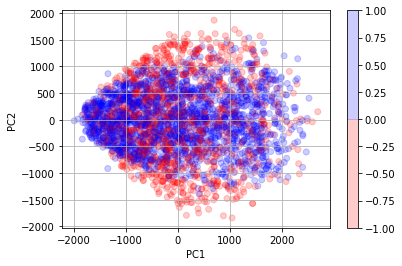

In [5]:
import matplotlib.colors
stand = preprocessing.StandardScaler().fit(Xtrain) #preporcessing via Standardtization
Xtrain_st = stand.transform(Xtrain) #
from sklearn.decomposition import PCA #import PCA

"""
procedure without sklearn.decomposition leads to same outcome!
ev, pc = np.linalg.eig(cm)
ev = np.abs(ev)
z = np.dot(Xtrain_st,pc) #projection
"""
pca784 = PCA(n_components=784) #fitting pca to training data
pca784.fit(Xtrain) #training PCA - here we do not standardtize, regarding a more vivid scatter plot in ii)
projected = pca784.transform(Xtrain) #projection
a = pca784.get_covariance()
print("The dimensions of X are",Xtrain.shape)
print("Covariance matrix Dimensionality is: ",a.shape)

r1 = 0 #np.random.randint(0,784) #thats an option to check to random features
r2 = 1 #np.random.randint(0,784)
if r1 == r2:
    r2 = r1+1
plt.figure() #vizualitation with scatter plot
plt.scatter(projected[:, r1], projected[:, r2], #r1th and second r2th component vizulalited (r1 and r2 choosen randomly)and reducing dimension from 784 to 2
            c = Ytrain, edgecolor='face', alpha=0.2, cmap= matplotlib.colors.ListedColormap(['red', 'blue'])
            );
plt.grid()
plt.xlabel('PC%i'%(1))
plt.ylabel('PC%i'%(2))
plt.colorbar();
plt.show()

Unfortunately, the scatter plot hardly gives us any information
The points points are clustered around the origin. The density of points increases the closer you get to the origin.
If you look closely, you can see that the density of the red labels (i.e. Y=-1) does not decrease as quickly as the blue labels (i.e. Y=1) when you move away vertically from the origin. 

### ii)

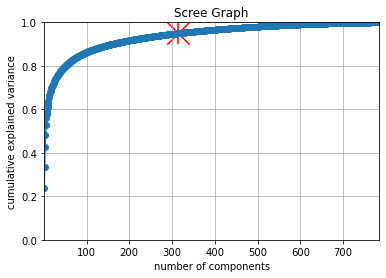


A dimension of 314 explain 0.9502 of the varinace in the training set,
whereas a dimension of 313 explain 0.9499 of the varinace in the training set


In [11]:
plt.figure()
plt.scatter(314.4, 0.95, s=500, marker='|', color ='red',alpha = 1) #min level
plt.scatter(315, 0.950155, s=500, marker='x', color ='red',alpha = 1) #nearest greater point
plt.plot(np.arange(len(pca784.explained_variance_ratio_))+1,np.cumsum(pca784.explained_variance_ratio_),'o-') #plot the scree graph
plt.axis([1,len(pca784.explained_variance_ratio_),0,1])
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');
plt.title('Scree Graph')
plt.grid()
plt.show()

print("\nA dimension of 314 explain",round(np.cumsum(pca784.explained_variance_ratio_)[314],4),"of the varinace in the training set,")
print("whereas a dimension of 313 explain",round(np.cumsum(pca784.explained_variance_ratio_)[313],4),"of the varinace in the training set")

By reading off and zooming in many times, one obtain that the dimension should be at least 314 (i.e. 315 or more)
in order to be able to explain at least 95% of the variance.

### iii)

In [115]:
d = 314 
# =============================================================================
# from ii) I would also take a similiar number.
# A good insight would give us the derivative of the scree graph. Well we cannot calculate it conretly
# but how it would look like, if you imagine that the first derivative represents the slope of a function.
# For the sake of simplicity, I will leave out the aspect of continuity here. First of all,
# we can see that the slope is positive everywhere and due to the asymptotic behaviour in the direction of y = 1,
# we can say that the slope decreases monotonically and even exponentially. It would make little sense to choose too few dimensions
# because the loss of information would be enormous compared to taking only one dimension more. However,
# if you look at values above 200, you will see that the difference between the dimensions becomes smaller and smaller.
# I wanted to express this effect with my first two sentences
# =============================================================================
pca784s = PCA(n_components=d) #fitting pca to training data
pca784s.fit(Xtrain_st)
Z = pca784s.transform(Xtrain_st) #projection
pc = pca784s.components_[0:d]  #principal component matrix
cm = pca784s.get_covariance() #covariance-matrix
ev = pca784s.explained_variance_ #eigen vector of covariance matrix of Xtrain

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

skf = StratifiedKFold(shuffle = True)

searchpara = [{'kernel': ['rbf'], 'gamma': [1e-3, 1e-4],'C': [0.001, 0.1, 1, 2, 3, 5, 8, 13, 21, 34],'class_weight': ['balanced']},
              {'kernel': ['poly'], 'coef0':[0,1] ,'gamma': [1e-3, 1e-4], 'degree': [0.5, 2, 3],'C': [0.001, 0.1, 1, 2, 3, 5, 8, 13, 21, 34],'class_weight': ['balanced']},
              {'kernel': ['sigmoid'], 'coef0':[0,1] ,'gamma': [1e-3, 1e-4], 'C': [0.001, 0.1, 1, 2, 3, 5, 8, 13, 21, 34],'class_weight': ['balanced']}]
#analyzed kernels: RBF, Polynomial and Sigmoid
gs = GridSearchCV(SVC(), searchpara, scoring='average_precision', cv= skf) #overwrite gs from linear svm with gridsearch
# to find best parameter for C and the best Kernel, such that average precision is optimized

gs.fit(Z, Ytrain)
try:
    gs.best_params_['degree']
    ksvm = SVC(C = gs.best_params_['C'], degree = gs.best_params_['degree'], gamma =  gs.best_params_['gamma'], kernel = gs.best_params_['kernel'], class_weight = 'balanced')
except KeyError:    
    ksvm = SVC(C = gs.best_params_['C'], gamma =  gs.best_params_['gamma'], kernel = gs.best_params_['kernel'], class_weight = 'balanced')
m_acc, std_acc = np.mean(cross_val_score(ksvm, Z, Ytrain, scoring = 'accuracy', cv=skf)),  np.std(cross_val_score(ksvm, Z, Ytrain, scoring = 'accuracy', cv=skf))
m_ar, std_ar = np.mean(cross_val_score(ksvm, Z, Ytrain, scoring = 'roc_auc', cv=skf)), np.std(cross_val_score(ksvm, Z, Ytrain, scoring = 'roc_auc', cv=skf))
m_ap, std_ap = np.mean(cross_val_score(ksvm, Z, Ytrain, scoring = 'average_precision', cv=skf)), np.std(cross_val_score(ksvm, Z, Ytrain, scoring = 'average_precision', cv=skf))

print("\nKernelized Support Vector Machine with ",gs.best_params_,"\nsuch that AUC-PR is optimal")
print("| cross validation results\t| predicted accuracy\t| AUC-ROC \t| Best AUC-PR \t|")
print('---------------------------------------------------------------------------------------------------')
print('| Total\t\t\t\t| mean = %1.4f \t| mean = %1.4f\t| mean = %1.4f\t|' % (m_acc, m_ar, m_ap))
print('| Total\t\t\t\t| std = %1.4f \t\t| std = %1.4f\t| std = %1.4f\t|' % (std_acc, std_ar, std_ap))


Kernelized Support Vector Machine with  {'C': 2, 'class_weight': 'balanced', 'gamma': 0.001, 'kernel': 'rbf'} 
such that AUC-PR is optimal
| cross validation results	| predicted accuracy	| AUC-ROC 	| Best AUC-PR 	|
---------------------------------------------------------------------------------------------------
| Total				| mean = 0.8430 	| mean = 0.9187	| mean = 0.9418	|
| Total				| std = 0.0132 		| std = 0.0040	| std = 0.0109	|


## Question 5

In [120]:
#import data
Xtest = np.loadtxt("Xtest.txt") #Xtrain: Training Data (each row is a single image)
Xtrain = np.loadtxt("Xtrain.txt") #Ytrain: Training labels
Ytrain = np.loadtxt("Ytrain.txt") #Xtest: Test labels (each row is a single image)


#%%
skf = StratifiedKFold(shuffle = True, n_splits = 8) #cross-validation over 8 Folds to get a more robust result
pca = PCA()
svc = SVC()

pipe = Pipeline(steps=[('scale', StandardScaler()), #our pipeline with the following steps: Stanadtize, find sufficient dimension using pca and kernelized SVM as classification tool
                       ('pca', pca), ('svc', svc)])

searchpara = [{'pca__n_components': [144, 256, 314],'svc__kernel': ['rbf'], 'svc__gamma': [1e-3, 1e-1, 1],
               'svc__C': [0.1, 1, 2, 3, 5, 8, 13, 34],'svc__class_weight': ['balanced']}, 
             {'pca__n_components': [144, 256, 314],'svc__kernel': ['poly'], 'svc__coef0':[0,1],
               'svc__gamma': [1e-3, 1e-1, 1], 'svc__degree': [2, 3],'svc__C': [0.1, 1, 2, 3, 5, 8, 13, 34],
               'svc__class_weight': ['balanced']}] #determine optimal hyperparameters

estimator = GridSearchCV(pipe, searchpara, scoring='f1', cv= skf,  n_jobs=-1, verbose= 2) #here we use the F as performence metric
estimator.fit(Xtrain, Ytrain)
print("The best parameters: {0}".format(estimator.best_params_))
pipe.set_params(**estimator.best_params_)
pipe.fit(Xtrain, Ytrain)
#same procedure as always 
m_acc, std_acc = np.mean(cross_val_score(pipe, Xtrain, Ytrain, scoring = 'accuracy', cv=skf)),  np.std(cross_val_score(pipe, Xtrain, Ytrain, scoring = 'accuracy', cv=skf))
m_ar, std_ar = np.mean(cross_val_score(pipe, Xtrain, Ytrain, scoring = 'roc_auc', cv=skf)), np.std(cross_val_score(pipe, Xtrain, Ytrain, scoring = 'roc_auc', cv=skf))
m_ap, std_ap = np.mean(cross_val_score(pipe, Xtrain, Ytrain, scoring = 'average_precision', cv=skf)), np.std(cross_val_score(pipe, Xtrain, Ytrain, scoring = 'average_precision', cv=skf))


print("\nI used a Kernelized Support Vector Machine with with the properties: ",estimator.best_params_)
print("| cross validation results\t| predicted accuracy\t| AUC-ROC \t| Best AUC-PR \t|")
print('---------------------------------------------------------------------------------------------------')
print('| Total\t\t\t\t| mean = %1.4f \t| mean = %1.4f\t| mean = %1.4f\t|' % (m_acc, m_ar, m_ap))
print('| Total\t\t\t\t| std = %1.4f \t\t| std = %1.4f\t| std = %1.4f\t|' % (std_acc, std_ar, std_ap))

Ypred = pipe.predict(Xtest) #saving the predicted Labels in the file Ypred.txt
np.savetxt("Ypred.txt", Ypred, fmt= '%i')

Fitting 8 folds for each of 360 candidates, totalling 2880 fits
The best parameters: {'pca__n_components': 144, 'svc__C': 8, 'svc__class_weight': 'balanced', 'svc__gamma': 0.001, 'svc__kernel': 'rbf'}

I used a Kernelized Support Vector Machine with with the properties:  {'pca__n_components': 144, 'svc__C': 8, 'svc__class_weight': 'balanced', 'svc__gamma': 0.001, 'svc__kernel': 'rbf'}
| cross validation results	| predicted accuracy	| AUC-ROC 	| Best AUC-PR 	|
---------------------------------------------------------------------------------------------------
| Total				| mean = 0.8460 	| mean = 0.9229	| mean = 0.9413	|
| Total				| std = 0.0129 		| std = 0.0126	| std = 0.0141	|


### Description
Why eight Folds?<br>
-> more accurate, reliable and robust classifier.<br>
-> eight is a good choice beacause we can split the 3000 examples equally in 375 examples per fold<br>
-> eight is not too large, so we do not expect exorbitant calculating times<br>
<br>
Why Standardtization?<br>
-> has proven to be very efficient in the past<br>
<br>
Why only RBF or Polynomial kearnelized SVM?<br>
-> has proven in the previous tasks a pretty high cross-validation performence<br>
<br>
How the choice of parameters came about<br>
-> pca__n_components: The scree graph gave a lot of information about which values I wanted to look at. From Q4 iii) we already knew that with 314 at least 0.95% of the variance could be explained. Poking around 314 does not make much sense, therefore the big steps. 144 and 256 are still big enough that you can't expect too much data loss, but still can save a lot of computation.<br>
-> gamma: element {0.001, 0.1, 1} catches a big spectrum of gammas - not too small and not to big influence of single example on classifier<br>
-> degree(poly): element {2,3} important here is to have a even potency and an odd potency because they look quite similar<br>
-> coef0(poly): element {0,1} <br>
-> C: element {0.1, 1, 2, 3, 5, 8, 13, 34} catches a big spectrum of Cs. Numbers from the beginning of the fibunacci series seemed to make sense to me since they are quite densely spread at the beginning and follow a certain system.<br>
F as perfomance metric? <br>
-> Instead of focusing on just one performance metric, I used one that takes into account 2: sensitivity and prescision. I expected with this method to get a higher over all cross-validation perfomance and got confirmed.